# spectrex mock example

End-to-end demonstration of the spectrex Phase 1 API using a synthetic
(mock) scene on a 500 × 20 pixel NIRISS/GR150R grism stamp.

The pipeline:
1. Load instrument configuration and PCA eigenspectra basis
2. Build (or load) the sparse forward operator **H**
3. Generate a mock scene — sparse PCA coefficient vector **ã**
4. Forward-model: disperse **ã** through **H** to produce a grism image
5. Recover **ã** from the dispersed image by LSQR
6. Repeat with Poisson + read noise to demonstrate the realistic case

RMSE is computed on reconstructed flux values `f(λ) = Φ @ a` so it is
physically meaningful and matches the parity plot axes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spectrex
from spectrex import (
    EigenspectraBasis,
    InstrumentConfig,
    NoiseModel,
    SciPySparseOperator,
    SpectralSolver,
)

# ── Paths ────────────────────────────────────────────────────────────────────
TESTDATA = Path("../testdata")
OPERATOR_CACHE = Path("operator_cache.npz")

# ── Configuration ─────────────────────────────────────────────────────────────
COLD_START = False    # set True to force operator rebuild from scratch
IMAGE_SHAPE = (500, 20)
SOURCE_DENSITY = 0.1  # fraction of pixels with injected sources
SEED = 42
N_COMPONENTS = 10     # must match eigenspectra CSV

rng = np.random.default_rng(SEED)

print(f"spectrex {spectrex.__version__}")

spectrex 0.1.1.dev2+gf26e39ef3.d20260505


## Step 1 — Instrument configuration & eigenspectra basis

`InstrumentConfig` loads the aXe grism config file, wavelength range, and
sensitivity curves. `EigenspectraBasis` loads the 10 Kurucz PCA eigenspectra
and interpolates them onto the instrument wavelength grid.

In [2]:
config = InstrumentConfig.from_files(
    conf_path=TESTDATA / "Config Files" / "GR150R.F150W.220725.conf",
    wavelengthrange_path=TESTDATA / "jwst_niriss_wavelengthrange_0002.asdf",
    sensitivity_dir=TESTDATA / "SenseConfig" / "wfss-grism-configuration",
    filter_name="F150W",
    n_wavelengths=150,
)

basis = EigenspectraBasis.from_csv(
    TESTDATA / "eigenspectra_kurucz.csv",
    config.wavelengths,
)

print(f"Wavelength range: {config.wavelengths[0]:.0f} – {config.wavelengths[-1]:.0f} Å")
print(f"Grism orders: {list(config.orders)}")
print(f"Basis components: {basis.n_components}")

Wavelength range: 12900 – 17100 Å
Grism orders: ['A', 'B', 'C', 'D', 'E']
Basis components: 10


## Step 2 — Forward operator

Builds the sparse matrix **H** (shape `n_pix × n_pix·n_components`) that maps
PCA coefficients to dispersed pixel values across all grism orders.

> **Note:** The first run builds **H** from scratch, which takes ~60 s for a
> 500 × 20 stamp. The result is cached to `operator_cache.npz`.
> Set `COLD_START = True` in the constants cell to force a rebuild.

In [3]:
import time

if OPERATOR_CACHE.exists() and not COLD_START:
    op = SciPySparseOperator.load(OPERATOR_CACHE)
    print(f"Operator loaded from {OPERATOR_CACHE}  "
          f"(shape {op._H.shape[0]} × {op._H.shape[1]})")
else:
    t0 = time.perf_counter()
    op = SciPySparseOperator.build(config, basis, IMAGE_SHAPE)
    op.save(OPERATOR_CACHE)
    elapsed = time.perf_counter() - t0
    print(f"Operator built in {elapsed:.1f} s — cached to {OPERATOR_CACHE}")
    print(f"Shape: {op._H.shape[0]} × {op._H.shape[1]}")

Operator built in 3.9 s — cached to operator_cache.npz
Shape: 10000 × 100000


## Step 3 — Mock scene

We inject sources at a random 10 % of pixels. For each active pixel we draw
random PCA coefficients, accept only if the reconstructed spectrum is
non-negative (physical), and store them in the flat coefficient vector **ã**.

The *direct image* is the broadband integrated flux I(x,y) = ∫ a(x,y,λ) dλ,
visualised as a 2-D stamp.

In [4]:
n_pix = IMAGE_SHAPE[0] * IMAGE_SHAPE[1]
n = basis.n_components

a_tilde = np.zeros(n_pix * n)

num_active = int(SOURCE_DENSITY * n_pix)
active_k = rng.choice(n_pix, size=num_active, replace=False)

MAX_TRIES = 50
n_placed = 0
for k in active_k:
    for _ in range(MAX_TRIES):
        flux = rng.uniform(-1, 1, size=n)
        if np.all(basis.reconstruct(flux) >= 0):
            a_tilde[k * n : (k + 1) * n] = flux
            n_placed += 1
            break

print(f"Sources placed: {n_placed} / {num_active} requested "
      f"({100 * n_placed / n_pix:.1f} % of pixels)")

direct = basis.broadband_image(a_tilde, IMAGE_SHAPE)
print(f"Direct image shape: {direct.shape},  max flux: {direct.max():.4f}")

Sources placed: 896 / 1000 requested (9.0 % of pixels)
Direct image shape: (500, 20),  max flux: 698067752.2096


## §1 — Noiseless recovery

Forward-model **ã** → dispersed grism image, then recover **ã** from the
dispersed image using LSQR. The support mask is built from the direct image
(non-zero pixels) so LSQR only solves for active columns of **H**.

In [5]:
dispersed = op.apply(a_tilde).reshape(IMAGE_SHAPE)

# Support mask: True at pixels known to have a source
support_mask = a_tilde != 0
print(f"Dispersed image range: [{dispersed.min():.4f}, {dispersed.max():.4f}]")
print(f"Active coefficients:   {support_mask.sum()} / {len(support_mask)}")

Dispersed image range: [0.0000, 17101.3035]
Active coefficients:   8960 / 100000


In [6]:
solver = SpectralSolver(op, max_iter=500, tolerance=1e-8)
recovered = solver.solve(dispersed, support_mask=support_mask)
print(f"Recovered vector shape: {recovered.shape}")

Recovered vector shape: (100000,)


In [7]:
active_indices = [k for k in range(n_pix) if np.any(a_tilde[k * n : (k + 1) * n] != 0)]

true_flux = np.concatenate(
    [basis.reconstruct(a_tilde[k * n : (k + 1) * n]) for k in active_indices]
)
rec_flux = np.concatenate(
    [basis.reconstruct(recovered[k * n : (k + 1) * n]) for k in active_indices]
)

rmse_noiseless = np.sqrt(np.mean((true_flux - rec_flux) ** 2))
print(f"Noiseless RMSE (flux): {rmse_noiseless:.6f}")

Noiseless RMSE (flux): 21287.860870


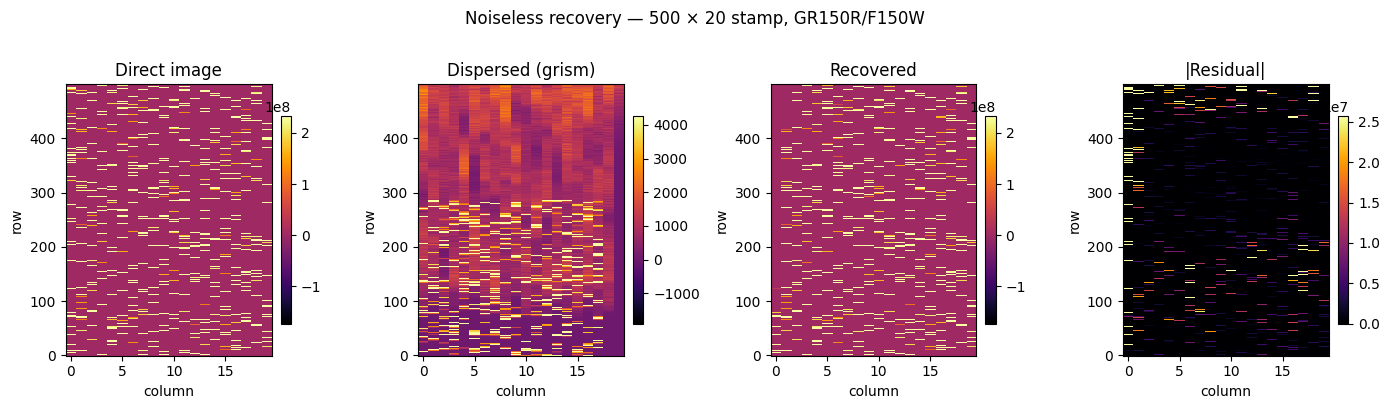

In [8]:
def _clip(arr, nsigma_lo=2, nsigma_hi=2):
    m, s = np.nanmean(arr), np.nanstd(arr)
    return m - nsigma_lo * s, m + nsigma_hi * s

recovered_img = basis.broadband_image(recovered, IMAGE_SHAPE)
residual_img  = np.abs(direct - recovered_img)

vmin_dr, vmax_dr = _clip(direct)                       # shared scale for Direct & Recovered
vmin_d2, vmax_d2 = _clip(dispersed)
vmax_res = np.nanmean(residual_img) + np.nanstd(residual_img)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
kw = dict(origin="lower", aspect="auto", interpolation="nearest", cmap="inferno")

im0 = axes[0].imshow(direct,        vmin=vmin_dr, vmax=vmax_dr, **kw)
im1 = axes[1].imshow(dispersed,     vmin=vmin_d2, vmax=vmax_d2, **kw)
im2 = axes[2].imshow(recovered_img, vmin=vmin_dr, vmax=vmax_dr, **kw)
im3 = axes[3].imshow(residual_img,  vmin=0,       vmax=vmax_res, **kw)

titles = ["Direct image", "Dispersed (grism)", "Recovered", "|Residual|"]
for ax, im, title in zip(axes, [im0, im1, im2, im3], titles):
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Noiseless recovery — 500 × 20 stamp, GR150R/F150W", y=1.01)
fig.tight_layout()
plt.show()

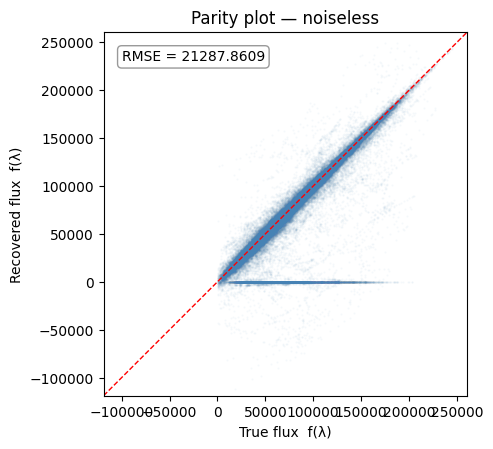

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(true_flux, rec_flux, s=2, alpha=0.05, linewidths=0, color="steelblue")
minv = min(true_flux.min(), rec_flux.min())
maxv = max(true_flux.max(), rec_flux.max())
ax.plot([minv, maxv], [minv, maxv], "r--", lw=1, label="1:1")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(minv, maxv)
ax.set_ylim(minv, maxv)
ax.set_xlabel("True flux  f(λ)")
ax.set_ylabel("Recovered flux  f(λ)")
ax.set_title("Parity plot — noiseless")
ax.text(0.05, 0.92, f"RMSE = {rmse_noiseless:.4f}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
fig.tight_layout()
plt.show()

## §2 — Noisy recovery

We add Gaussian noise approximating Poisson + detector read noise
(`read_noise = 5 e⁻`) using `NoiseModel.sample()`.  The same support mask
and LSQR solver are used; the only change is the input image.

This is the realistic operating regime for real JWST data.

In [10]:
noise_model = NoiseModel(read_noise=5.0)
noisy_dispersed = noise_model.sample(dispersed, rng)
print(f"Noisy dispersed range: [{noisy_dispersed.min():.4f}, {noisy_dispersed.max():.4f}]")
print(f"Added noise std (mean over pixels): "
      f"{np.std(noisy_dispersed - dispersed):.4f}")

Noisy dispersed range: [-24.6412, 16906.7927]
Added noise std (mean over pixels): 34.1373


In [11]:
noisy_recovered = solver.solve(noisy_dispersed, support_mask=support_mask)
print(f"Noisy recovered vector shape: {noisy_recovered.shape}")

Noisy recovered vector shape: (100000,)


In [12]:
noisy_rec_flux = np.concatenate(
    [basis.reconstruct(noisy_recovered[k * n : (k + 1) * n]) for k in active_indices]
)

rmse_noisy = np.sqrt(np.mean((true_flux - noisy_rec_flux) ** 2))
print(f"Noiseless RMSE: {rmse_noiseless:.6f}")
print(f"Noisy RMSE:     {rmse_noisy:.6f}")
print(f"RMSE ratio:     {rmse_noisy / rmse_noiseless:.2f}×")

Noiseless RMSE: 21287.860870
Noisy RMSE:     25840.669446
RMSE ratio:     1.21×


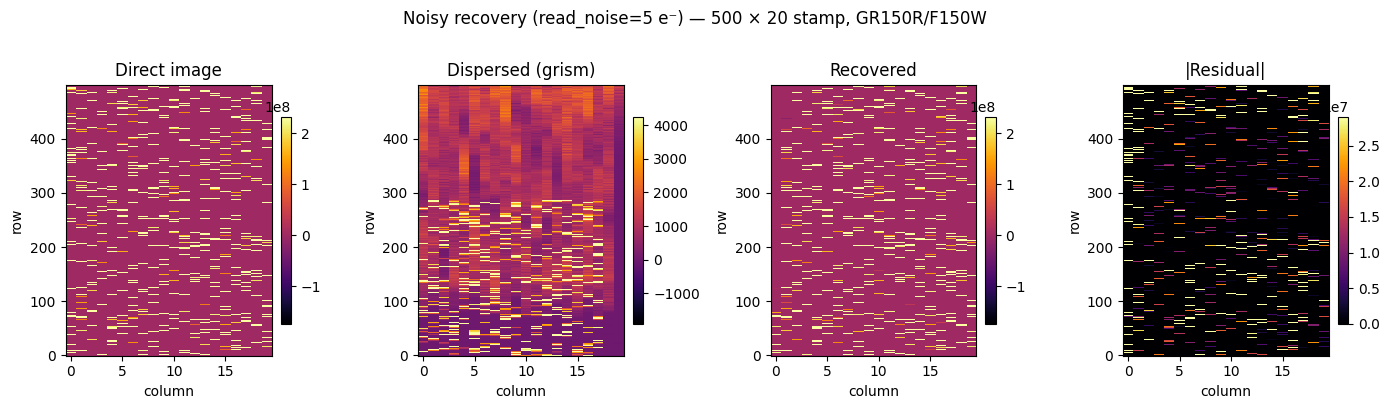

In [13]:
noisy_recovered_img = basis.broadband_image(noisy_recovered, IMAGE_SHAPE)
noisy_residual_img  = np.abs(direct - noisy_recovered_img)

vmax_nres = np.nanmean(noisy_residual_img) + np.nanstd(noisy_residual_img)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

im0 = axes[0].imshow(direct,             vmin=vmin_dr,   vmax=vmax_dr,   **kw)
im1 = axes[1].imshow(noisy_dispersed,    vmin=vmin_d2,   vmax=vmax_d2,   **kw)
im2 = axes[2].imshow(noisy_recovered_img,vmin=vmin_dr,   vmax=vmax_dr,   **kw)
im3 = axes[3].imshow(noisy_residual_img, vmin=0,         vmax=vmax_nres, **kw)

for ax, im, title in zip(axes, [im0, im1, im2, im3], titles):
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Noisy recovery (read_noise=5 e⁻) — 500 × 20 stamp, GR150R/F150W", y=1.01)
fig.tight_layout()
plt.show()

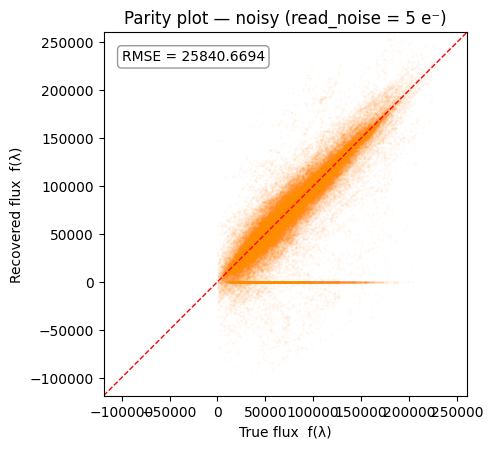

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(true_flux, noisy_rec_flux, s=2, alpha=0.05, linewidths=0, color="darkorange")
ax.plot([minv, maxv], [minv, maxv], "r--", lw=1, label="1:1")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(minv, maxv)
ax.set_ylim(minv, maxv)
ax.set_xlabel("True flux  f(λ)")
ax.set_ylabel("Recovered flux  f(λ)")
ax.set_title("Parity plot — noisy (read_noise = 5 e⁻)")
ax.text(0.05, 0.92, f"RMSE = {rmse_noisy:.4f}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
fig.tight_layout()
plt.show()

## Next steps

The parity plots above give a single RMSE figure for one source density.
To quantify how recovery quality degrades as the field becomes more crowded,
see the planned sweep notebook:

```
notebooks/analysis_rmse_vs_density.ipynb   (TODO)
```

That notebook will define a `run_pipeline(a_tilde, op, basis, noise_model=None)`
helper and sweep `SOURCE_DENSITY` over ~5–8 values, plotting RMSE vs density
for both the noiseless and noisy cases.  This sweep is important for
establishing the credibility of the method in crowded NIRISS fields.